In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [18]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [51]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [78]:
grouped_df

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
...,...,...
200,2018-08-26,5302
201,2018-08-28,5983
202,2018-08-29,4969
203,2018-08-30,4648


Нарисуйте график продаж у `grouped_df`

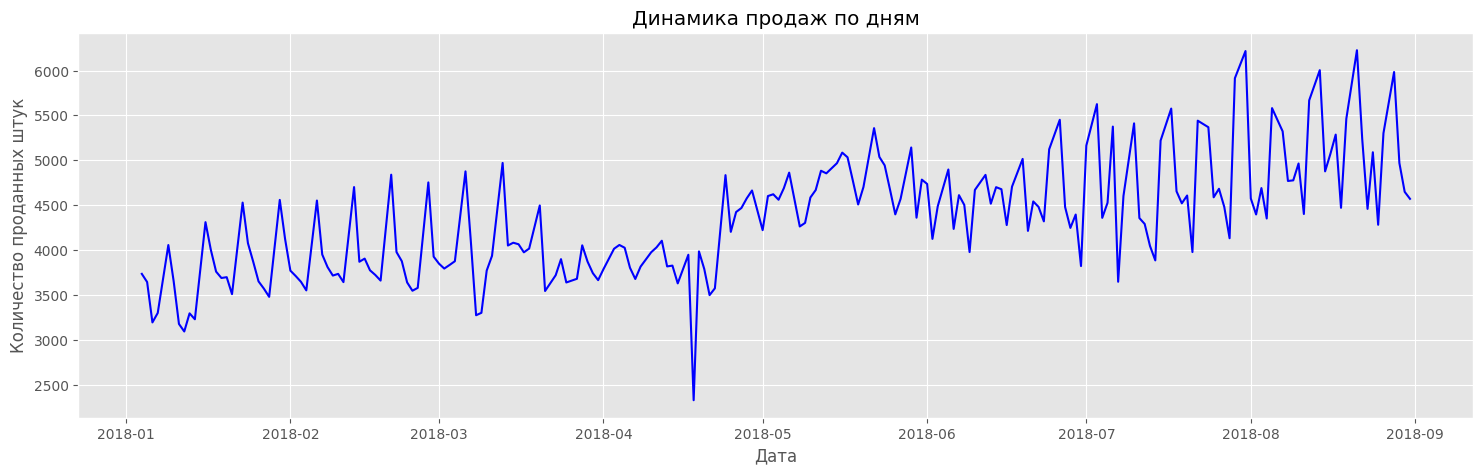

In [129]:
plt.figure(figsize=(18, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='blue')
plt.title('Динамика продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество проданных штук')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Наблюдается отчетливый восходящий тренд. Если в начале года (январь–февраль) продажи колебались в районе 3500-4500 единиц, то к августу–сентябрю средний уровень поднялся до 4500–6000 единиц. Бизнес явно растет.

График имеет пилообразную форму, что может говаорить о цикличности продаж (например в течении недели будние v.s. выходные)

Также в графики замечаются аномалии:
1. Глубокий провал в апреле, где продажи упали ниже 2500 шт.
2. Майский скачек, после которого график закрепился на более высоком уровне и дальше продолжил рост.
3. Максимальные продажи замеченны к концу лета, где начиная с последней недели июля продажи поднимались 4 раза выше 6000 шт


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [56]:
outlier_row = df.loc[df['Количество'].idxmax()]
print(outlier_row)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [59]:
filtered_df = df[(df['Склад'] == 3) & (df['Дата'].dt.month.isin([6, 7, 8])) & (df['Дата'].dt.dayofweek == 2)]

result = filtered_df.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)
result

,Количество
Номенклатура,
product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [118]:
weather = pd.read_excel('архив.xls', sheet_name='Архив Погоды rp5')
weather = weather[['Местное время в Астане', 'T']].rename(columns={'Местное время в Астане': 'DT'})
weather['DT'] = pd.to_datetime(weather['DT'], dayfirst=True)
weather['Дата'] = weather['DT'].dt.date
daily_temp = weather.groupby('Дата')['T'].mean().reset_index()
daily_temp['Дата'] = pd.to_datetime(daily_temp['Дата'])
df_merged = pd.merge(grouped_df, daily_temp, on='Дата').sort_values('Дата')

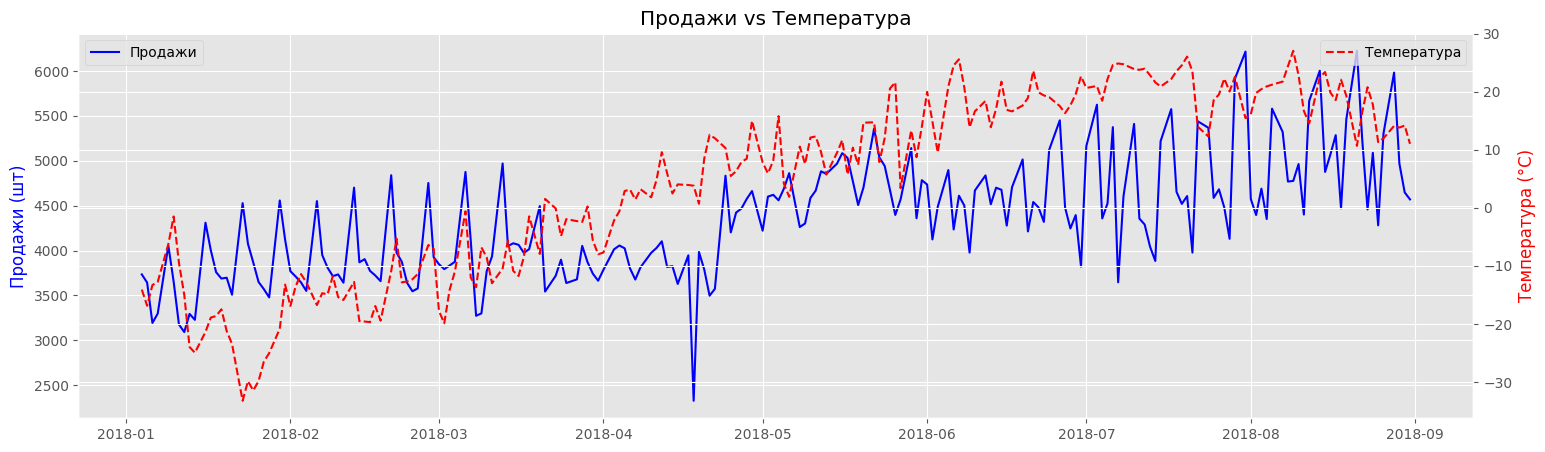

In [128]:
plt.figure(figsize=(18, 5))

ax1 = plt.gca()
ax1.plot(df_merged['Дата'], df_merged['Количество'], label='Продажи', color='blue')
ax1.set_ylabel('Продажи (шт)', color='blue')

ax2 = ax1.twinx()
ax2.plot(df_merged['Дата'], df_merged['T'], label='Температура', color='red', linestyle='--')
ax2.set_ylabel('Температура (°C)', color='red')

plt.title('Продажи vs Температура')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()